In [1]:
import pandas as pd

df = pd.read_csv('/Users/adityakatoch/Downloads/Sydney_Housing_Data.csv')

# Remove completely empty rows
df = df.dropna(how='all')

# Remove completely empty columns
df = df.dropna(axis=1, how='all')
df['pincode'] = df['pincode'].astype(int)


df.head()


,Address,Suburb,SalePrice,Bedrooms,Bathrooms,CarSpace,PropertyType,LandSize,pincode
0,20/11 Hunter Street,Parramatta,570000.0,2.0,2.0,1.0,Apartment,108.0,2150
1,27/7 Aird St,Parramatta,650000.0,2.0,2.0,1.0,Apartment,121.0,2150
2,4/7 Aird St,Parramatta,580000.0,2.0,2.0,1.0,Apartment,NaN,2150
3,65 & 67 Victoria Road,Parramatta,1300000.0,8.0,4.0,8.0,Semi-detached,NaN,2150
4,69 Fennell Street,Parramatta,1900000.0,3.0,2.0,2.0,House,911.0,2150


In [2]:
print("Dataset shape:", df.shape)
print("Number of properties:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset shape: (106, 9)
Number of properties: 106
Number of columns: 9


In [3]:
print(df['Suburb'].value_counts())

Suburb
Parramatta      36
Blacktown       35
Campbelltown    35
Name: count, dtype: int64


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Address       106 non-null    str    
 1   Suburb        106 non-null    str    
 2   SalePrice     106 non-null    float64
 3   Bedrooms      106 non-null    float64
 4   Bathrooms     106 non-null    float64
 5   CarSpace      102 non-null    float64
 6   PropertyType  106 non-null    str    
 7   LandSize      97 non-null     float64
 8   pincode       106 non-null    int64  
dtypes: float64(5), int64(1), str(3)
memory usage: 7.6 KB


In [5]:
print(df.isnull().sum())

Address         0
Suburb          0
SalePrice       0
Bedrooms        0
Bathrooms       0
CarSpace        4
PropertyType    0
LandSize        9
pincode         0
dtype: int64


In [6]:
print("Total properties:", len(df))

print("\nProperties in each suburb:")
print(df['Suburb'].value_counts())

Total properties: 106

Properties in each suburb:
Suburb
Parramatta      36
Blacktown       35
Campbelltown    35
Name: count, dtype: int64


In [7]:
print(df.columns)

Index(['Address', 'Suburb', 'SalePrice', 'Bedrooms', 'Bathrooms', 'CarSpace',
       'PropertyType', 'LandSize', 'pincode'],
      dtype='str')


In [8]:
print(df['PropertyType'].value_counts())

PropertyType
House            80
Apartment        19
Semi-detached     3
Townhouse         2
Villa             1
Terrace           1
Name: count, dtype: int64


In [9]:
df.describe()

,SalePrice,Bedrooms,Bathrooms,CarSpace,LandSize,pincode
count,1.060000e+02,106.000000,106.000000,102.000000,97.000000,106.000000
mean,1.085017e+06,3.452830,1.688679,1.921569,514.242268,2284.726415
std,3.747506e+05,1.235445,0.820722,1.376509,236.086419,194.192174
min,5.200000e+05,2.000000,1.000000,1.000000,91.000000,2148.000000
25%,8.725000e+05,3.000000,1.000000,1.000000,381.000000,2148.000000
50%,9.814440e+05,3.000000,2.000000,2.000000,556.000000,2150.000000
75%,1.231500e+06,4.000000,2.000000,2.000000,651.500000,2560.000000
max,2.300000e+06,8.000000,4.000000,8.000000,1182.000000,2560.000000


In [10]:
print("Duplicate properties:", df.duplicated(subset=['Address', 'Suburb']).sum())

Duplicate properties: 0


**Task 2 **


Handling Missing Values:
Before analysing the data, I checked the median CarSpace and LandSize for each suburb. I used suburb-specific medians because the typical property characteristics differ between the three suburbs, especially the much smaller land sizes in Parramatta.

In [11]:
print(df.groupby('Suburb')[['CarSpace', 'LandSize']].median())

              CarSpace  LandSize
Suburb                          
Blacktown          2.0     569.0
Campbelltown       1.0     587.0
Parramatta         1.0     127.5


I filled the missing CarSpace and LandSize values using the median of the corresponding suburb rather than using one value for the entire dataset.

In [12]:
df['CarSpace'] = df['CarSpace'].fillna(
    df.groupby('Suburb')['CarSpace'].transform('median')
)

df['LandSize'] = df['LandSize'].fillna(
    df.groupby('Suburb')['LandSize'].transform('median')
)

print(df.isnull().sum())

Address         0
Suburb          0
SalePrice       0
Bedrooms        0
Bathrooms       0
CarSpace        0
PropertyType    0
LandSize        0
pincode         0
dtype: int64


I used a histogram to understand how sale prices are distributed and to identify whether most properties fall within a similar price range or whether unusually high/low values are present.

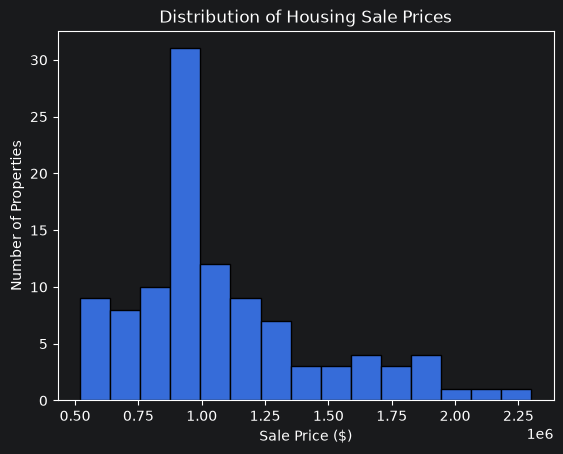

In [13]:
import matplotlib.pyplot as plt

plt.hist(df['SalePrice'], bins=15, edgecolor='black')
plt.xlabel('Sale Price ($)')
plt.ylabel('Number of Properties')
plt.title('Distribution of Housing Sale Prices')
plt.show()

I used a boxplot to compare the distribution and spread of sale prices across Parramatta, Blacktown and Campbelltown.

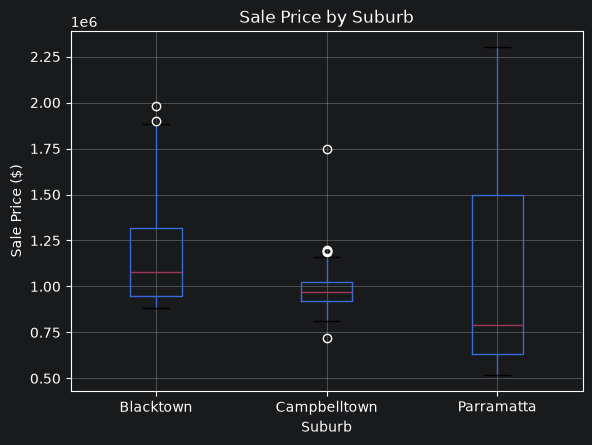

In [14]:
df.boxplot(column='SalePrice', by='Suburb')

plt.title('Sale Price by Suburb')
plt.suptitle('')
plt.xlabel('Suburb')
plt.ylabel('Sale Price ($)')
plt.show()

I also calculated the mean, median, minimum and maximum prices for each suburb to support the visual comparison with actual values.

In [15]:
print(df.groupby('Suburb')['SalePrice'].agg(['mean', 'median', 'min', 'max']))

                      mean     median       min        max
Suburb                                                    
Blacktown     1.189886e+06  1080000.0  880000.0  1980000.0
Campbelltown  1.003013e+06   970500.0  720000.0  1750000.0
Parramatta    1.062789e+06   790000.0  520000.0  2300000.0


Blacktown had the highest sample median at 1.08 million, followed by Campbelltown at 970,500, while Parramatta had a lower median
790,000 but a much wider price range of 520,000–2.3 million.

In [16]:
print(df.nlargest(5, 'SalePrice')[
    ['Address', 'Suburb', 'SalePrice', 'Bedrooms',
     'Bathrooms', 'PropertyType', 'LandSize']
])

              Address      Suburb  SalePrice  Bedrooms  Bathrooms  \
11  124 Thomas Street  Parramatta  2300000.0       3.0        1.0   
10     33 Rosehill St  Parramatta  2080000.0       4.0        1.0   
36  29 Stanley Street   Blacktown  1980000.0       5.0        4.0   
4   69 Fennell Street  Parramatta  1900000.0       3.0        2.0   
7    7A Gaggin Street  Parramatta  1900000.0       4.0        3.0   

   PropertyType  LandSize  
11        House     739.0  
10        House     691.0  
36        House     556.0  
4         House     911.0  
7         House     127.5  


I calculated correlations to examine how strongly the numerical property characteristics were associated with SalePrice.

In [17]:
numeric_data = df[
    ['SalePrice', 'Bedrooms', 'Bathrooms', 'CarSpace', 'LandSize']
]

print(numeric_data.corr())

           SalePrice  Bedrooms  Bathrooms  CarSpace  LandSize
SalePrice   1.000000  0.597974   0.386598  0.335438  0.495453
Bedrooms    0.597974  1.000000   0.675744  0.557326  0.318646
Bathrooms   0.386598  0.675744   1.000000  0.479538 -0.181339
CarSpace    0.335438  0.557326   0.479538  1.000000  0.147584
LandSize    0.495453  0.318646  -0.181339  0.147584  1.000000


Before creating additional features, I expected Suburb, Bedrooms and LandSize to have the strongest influence on sale price. Suburb represents location and differences between local housing markets. Bedrooms provide an indication of property capacity/size, while LandSize represents the amount of land available and may contribute to property value.

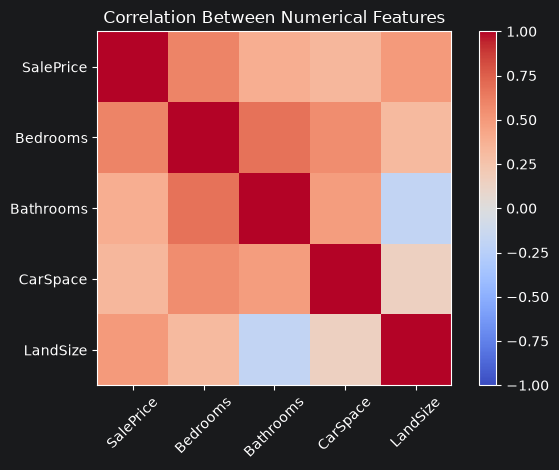

In [18]:
corr = numeric_data.corr()

plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title('Correlation Between Numerical Features')
plt.tight_layout()
plt.show()

I created TotalRooms by combining bedrooms and bathrooms. The purpose was to create a simple feature representing the overall room capacity of each property and investigate whether this had a stronger relationship with sale price.

In [19]:
print(df.groupby('Suburb')[['CarSpace', 'LandSize']].median())

              CarSpace  LandSize
Suburb                          
Blacktown          2.0     569.0
Campbelltown       1.0     587.0
Parramatta         1.0     127.5


TotalRooms had a moderate positive correlation of 0.559 with SalePrice. However, this was slightly lower than the 0.598 correlation obtained for bedrooms alone. Therefore, the engineered feature behaved in the expected positive direction but did not provide a stronger simple relationship with price than bedrooms by itself.

In [20]:
outlier = df[df['SalePrice'] > 3000000]

print(outlier[
    ['Address', 'Suburb', 'SalePrice', 'Bedrooms',
     'Bathrooms', 'CarSpace', 'PropertyType', 'LandSize']
])

Empty DataFrame
Columns: [Address, Suburb, SalePrice, Bedrooms, Bathrooms, CarSpace, PropertyType, LandSize]
Index: []


In [21]:
df['TotalRooms'] = df['Bedrooms'] + df['Bathrooms']

print(df[
    ['Bedrooms', 'Bathrooms', 'TotalRooms']
].head())

   Bedrooms  Bathrooms  TotalRooms
0       2.0        2.0         4.0
1       2.0        2.0         4.0
2       2.0        2.0         4.0
3       8.0        4.0        12.0
4       3.0        2.0         5.0


In [22]:
print(df[['SalePrice', 'TotalRooms']].corr())

            SalePrice  TotalRooms
SalePrice    1.000000    0.558902
TotalRooms   0.558902    1.000000


Trends Over Time:
A temporal analysis could not be performed because SaleDate was not included in my manually collected dataset. This is a limitation of the current data. In future work, adding the sale date would allow changes in property prices across different time periods to be investigated.

Task 3

Model Selection and Expected Performance
I selected three regression models representing different modelling approaches:
Linear Regression: I selected this as a simple baseline model. It is easy to interpret and can model general relationships between property features and sale price, but it may underfit if housing prices depend on complex or non-linear relationships.
Decision Tree Regression: I selected a decision tree because it can learn non-linear relationships and interactions between features without assuming a linear relationship. However, a deep tree may overfit a relatively small dataset such as mine.
Random Forest Regression: I selected Random Forest because it combines multiple decision trees, which can capture non-linear patterns while reducing the overfitting of an individual tree. Its disadvantage is greater complexity and lower interpretability.
Expected best model: Before training, I expect Random Forest to perform best because housing prices are likely influenced by interactions between location, property type, land size, bedrooms and other features. I expect Linear Regression to provide a useful baseline, while the Decision Tree may be more sensitive to the small dataset.


SalePrice was selected as the prediction target. I excluded Address because it identifies individual properties rather than representing a general property characteristic. I also used Suburb as the main location feature instead of postcode

In [23]:
X = df[
    ['Suburb', 'Bedrooms', 'Bathrooms', 'CarSpace',
     'PropertyType', 'LandSize', 'TotalRooms']
]

y = df['SalePrice']

Suburb and PropertyType are categorical variables, so I converted them into numerical dummy variables using one-hot encoding. drop_first=True was used to avoid keeping a redundant dummy category.

In [24]:
X = pd.get_dummies(
    X,
    columns=['Suburb', 'PropertyType'],
    drop_first=True
)

print(X.head())
print("Model dataset shape:", X.shape)

   Bedrooms  Bathrooms  CarSpace  LandSize  TotalRooms  Suburb_Campbelltown  \
0       2.0        2.0       1.0     108.0         4.0                False   
1       2.0        2.0       1.0     121.0         4.0                False   
2       2.0        2.0       1.0     127.5         4.0                False   
3       8.0        4.0       8.0     127.5        12.0                False   
4       3.0        2.0       2.0     911.0         5.0                False   

   Suburb_Parramatta  PropertyType_House  PropertyType_Semi-detached  \
0               True               False                       False   
1               True               False                       False   
2               True               False                       False   
3               True               False                        True   
4               True                True                       False   

   PropertyType_Terrace  PropertyType_Townhouse  PropertyType_Villa  
0                 Fals

In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import KFold, cross_validate

In [26]:
models = {
    'Linear Regression': LinearRegression(),

    'Decision Tree': DecisionTreeRegressor(
        max_depth=5,
        random_state=42
    ),

    'Random Forest': RandomForestRegressor(
        n_estimators=100,
        max_depth=5,
        random_state=42
    )
}

In [27]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

I used 5-fold cross-validation so each model could be evaluated across multiple train/test splits rather than relying on one split. The dataset is shuffled before creating the folds, while random_state=42 keeps the experiment reproducible.

In [28]:
import numpy as np

results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X,
        y,
        cv=kf,
        scoring={
            'MAE': 'neg_mean_absolute_error',
            'MSE': 'neg_mean_squared_error',
            'R2': 'r2'
        },
        return_train_score=True
    )

    train_r2 = scores['train_R2'].mean()
    test_r2 = scores['test_R2'].mean()

    mae = -scores['test_MAE'].mean()
    rmse = np.sqrt(-scores['test_MSE'].mean())

    results.append([
        name,
        mae,
        rmse,
        train_r2,
        test_r2
    ])

In [29]:
results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'MAE',
        'RMSE',
        'Train R2',
        'CV R2'
    ]
)

print(results_df.round(3))

               Model         MAE        RMSE  Train R2  CV R2
0  Linear Regression  130572.437  212392.800     0.852  0.613
1      Decision Tree  154215.654  243030.967     0.948  0.491
2      Random Forest  118231.440  188173.184     0.951  0.683


I first compared the cross-validation R² of all three models. A higher CV R² indicates better performance on unseen validation data.

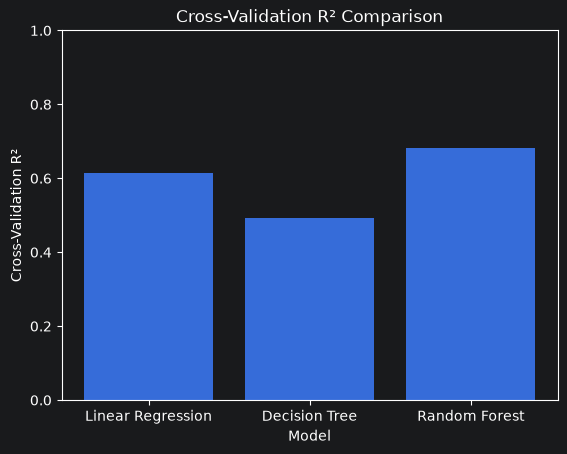

In [30]:
plt.bar(
    results_df['Model'],
    results_df['CV R2']
)

plt.xlabel('Model')
plt.ylabel('Cross-Validation R²')
plt.title('Cross-Validation R² Comparison')
plt.ylim(0, 1)
plt.show()

I also compared MAE and RMSE for all three models. Lower values are preferred because they represent smaller prediction errors. RMSE gives greater weight to larger errors than MAE.

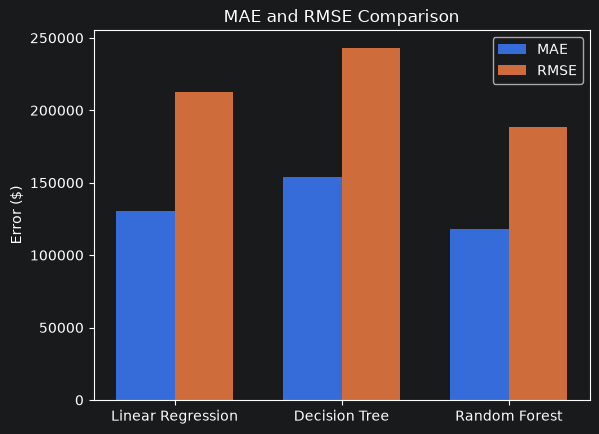

In [31]:
x = np.arange(len(results_df))
width = 0.35

plt.bar(
    x - width/2,
    results_df['MAE'],
    width,
    label='MAE'
)

plt.bar(
    x + width/2,
    results_df['RMSE'],
    width,
    label='RMSE'
)

plt.xticks(x, results_df['Model'])
plt.ylabel('Error ($)')
plt.title('MAE and RMSE Comparison')
plt.legend()
plt.show()

I compared training R² with cross-validation R² to investigate model behaviour. A large gap where training performance is much higher than validation performance may indicate overfitting.

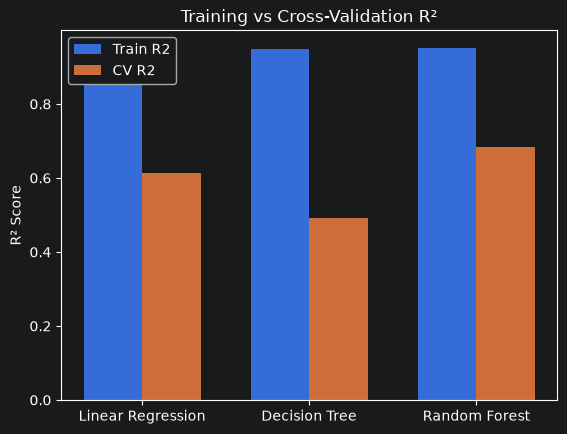

In [32]:
x = np.arange(len(results_df))
width = 0.35

plt.bar(
    x - width/2,
    results_df['Train R2'],
    width,
    label='Train R2'
)

plt.bar(
    x + width/2,
    results_df['CV R2'],
    width,
    label='CV R2'
)

plt.xticks(x, results_df['Model'])
plt.ylabel('R² Score')
plt.title('Training vs Cross-Validation R²')
plt.legend()
plt.show()

To investigate the effect of complexity, I trained Decision Trees with different maximum depths. Shallow trees have fewer splits and may underfit, while deeper trees can capture more patterns but may eventually overfit the training data.

In [33]:
depths = [2, 3, 5, 8, 10, None]

depth_results = []

for depth in depths:

    tree = DecisionTreeRegressor(
        max_depth=depth,
        random_state=42
    )

    scores = cross_validate(
        tree,
        X,
        y,
        cv=kf,
        scoring='r2',
        return_train_score=True
    )

    depth_results.append([
        str(depth),
        scores['train_score'].mean(),
        scores['test_score'].mean()
    ])

depth_df = pd.DataFrame(
    depth_results,
    columns=['Max Depth', 'Train R2', 'CV R2']
)

print(depth_df.round(3))

  Max Depth  Train R2  CV R2
0         2     0.527  0.178
1         3     0.739  0.242
2         5     0.948  0.491
3         8     0.989  0.573
4        10     0.995  0.480
5      None     0.998  0.492


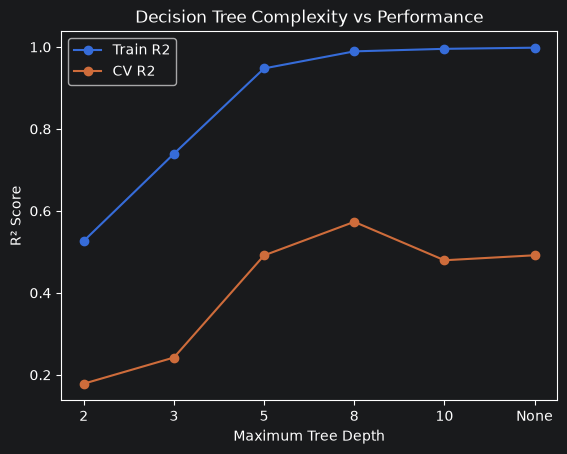

In [34]:
plt.plot(
    depth_df['Max Depth'],
    depth_df['Train R2'],
    marker='o',
    label='Train R2'
)

plt.plot(
    depth_df['Max Depth'],
    depth_df['CV R2'],
    marker='o',
    label='CV R2'
)

plt.xlabel('Maximum Tree Depth')
plt.ylabel('R² Score')
plt.title('Decision Tree Complexity vs Performance')
plt.legend()
plt.show()

I used the Random Forest selected in Part 3 to generate predictions using 5-fold cross-validation. This means each property's prediction is made when that property is outside the training fold, giving a more realistic way to investigate prediction failures.

In [35]:
from sklearn.model_selection import cross_val_predict

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

predictions = cross_val_predict(
    rf_model,
    X,
    y,
    cv=kf
)

print(predictions[:10])

[ 625622.38009213  648740.36563437  633745.12753913 1039029.01412698
 1574794.29566009 1558156.3373516   620717.18975469  924011.47075325
  626126.47394272  665248.65594295]


I compared the actual sale price of each property with its predicted price. I calculated the absolute error so that I could identify the properties where the model's prediction was furthest from the real sale price.

I sorted the properties by absolute prediction error and selected the five largest errors. I included their property characteristics so I could investigate possible reasons why these particular properties were difficult for the model to predict.

In [41]:
suburb_medians = df.groupby('Suburb')[
    ['SalePrice', 'Bedrooms', 'Bathrooms', 'CarSpace', 'LandSize']
].median()

print(suburb_medians)

              SalePrice  Bedrooms  Bathrooms  CarSpace  LandSize
Suburb                                                          
Blacktown     1080000.0       3.0        1.0       2.0     569.0
Campbelltown   970500.0       3.0        1.0       1.0     587.0
Parramatta     790000.0       3.0        2.0       1.0     127.5


In [45]:
from sklearn.model_selection import cross_val_predict

predictions = cross_val_predict(
    rf_model,
    X,
    y,
    cv=5
)

error_df = df.copy()
error_df['PredictedPrice'] = predictions
error_df['AbsoluteError'] = abs(
    error_df['SalePrice'] - error_df['PredictedPrice']
)

error_df['PercentageError'] = (
    error_df['AbsoluteError'] / error_df['SalePrice']
) * 100

largest_errors = error_df.sort_values(
    'AbsoluteError',
    ascending=False
).head(5)

print(largest_errors[[
    'Address', 'Suburb', 'SalePrice',
    'PredictedPrice', 'AbsoluteError',
    'PercentageError', 'Bedrooms',
    'Bathrooms', 'CarSpace',
    'PropertyType', 'LandSize'
]].to_string(index=False))

                Address     Suburb  SalePrice  PredictedPrice  AbsoluteError  PercentageError  Bedrooms  Bathrooms  CarSpace PropertyType  LandSize
      124 Thomas Street Parramatta  2300000.0    1.551481e+06  748518.586241        32.544286       3.0        1.0       1.0        House     739.0
       7A Gaggin Street Parramatta  1900000.0    1.168375e+06  731624.880952        38.506573       4.0        3.0       3.0        House     127.5
  UNIT 52/3 Good Street Parramatta   827500.0    1.506250e+06  678750.390909        82.024216       4.0        2.0       2.0    Apartment     200.0
907/6-10 Charles Street Parramatta   720000.0    1.340003e+06  620003.020274        86.111531       3.0        2.0       1.0    Apartment     120.0
   108/36 Cowper Street Parramatta   750000.0    1.359357e+06  609356.770274        81.247569       3.0        2.0       2.0    Apartment     110.0


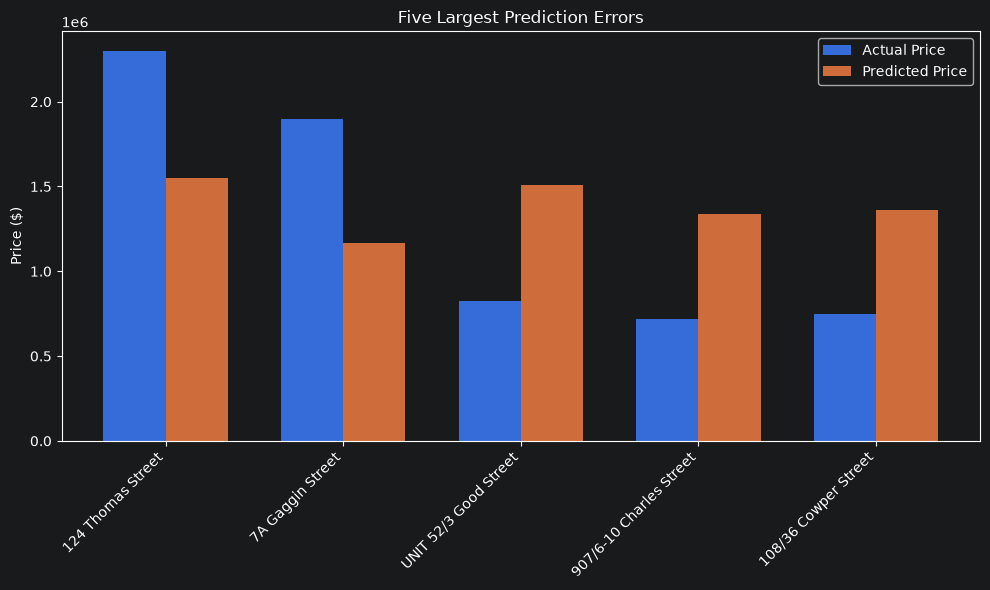

In [46]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(largest_errors))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    largest_errors['SalePrice'],
    width,
    label='Actual Price'
)

plt.bar(
    x + width/2,
    largest_errors['PredictedPrice'],
    width,
    label='Predicted Price'
)

plt.xticks(
    x,
    largest_errors['Address'],
    rotation=45,
    ha='right'
)

plt.ylabel('Price ($)')
plt.title('Five Largest Prediction Errors')
plt.legend()
plt.tight_layout()
plt.show()

In [47]:
import joblib

rf_model.fit(X, y)

joblib.dump(rf_model, 'housing_model.pkl')

print("Model saved successfully.")

Model saved successfully.


In [48]:
joblib.dump(X.columns.tolist(), 'model_columns.pkl')

print("Model columns saved successfully.")

Model columns saved successfully.
